In [5]:
# ---------- Step 1: Install & Import ----------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

#  visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [6]:
# ---------- Step 2: Load Dataset ----------

from google.colab import files
print("Please upload Crop_recommendation.csv")
uploaded = files.upload()

df = pd.read_csv("Crop_recommendation.csv")

print(f"\n✅ Dataset loaded successfully!")
print(f"📊 Shape  : {df.shape}")
print(f"🌾 Crops  : {df['label'].nunique()} unique crops")
print(f"\nFirst 5 rows:")
print(df.head())

Please upload Crop_recommendation.csv


Saving Crop_recommendation.csv to Crop_recommendation (1).csv

✅ Dataset loaded successfully!
📊 Shape  : (2200, 8)
🌾 Crops  : 22 unique crops

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [7]:
# ---------- Step 3: Basic Info (simplified) ----------

print("\n--- Dataset Overview ---")
print(f"Total samples: {len(df)}")
print(f"Features: {', '.join(df.columns[:-1])}")
print(f"Target crops: {', '.join(df['label'].unique())}")

# Quick check for missing values
if df.isnull().sum().sum() == 0:
    print("✅ No missing values found")



--- Dataset Overview ---
Total samples: 2200
Features: N, P, K, temperature, humidity, ph, rainfall
Target crops: rice, maize, chickpea, kidneybeans, pigeonpeas, mothbeans, mungbean, blackgram, lentil, pomegranate, banana, mango, grapes, watermelon, muskmelon, apple, orange, papaya, coconut, cotton, jute, coffee
✅ No missing values found


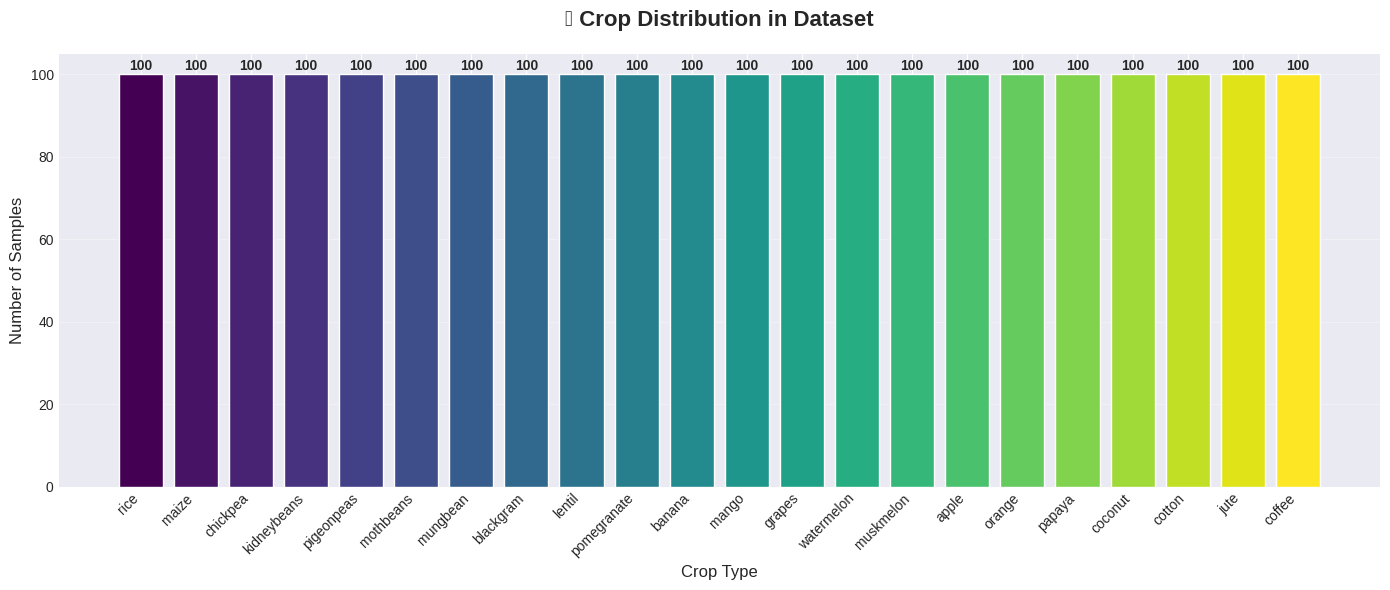

In [8]:
# ---------- Step 4:  VISUALIZATIONS ----------

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
feature_labels = ['Nitrogen', 'Phosphorus', 'Potassium',
                  'Temperature', 'Humidity', 'pH', 'Rainfall']

# 4.1 Crop Distribution - bar chart
plt.figure(figsize=(14, 6))
crop_counts = df['label'].value_counts()
colors = plt.cm.viridis(np.linspace(0, 1, len(crop_counts)))
bars = plt.bar(crop_counts.index, crop_counts.values, color=colors, edgecolor='white', linewidth=1)

# Add value labels on bars
for bar, count in zip(bars, crop_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontsize=10, fontweight='bold')

plt.title('🌾 Crop Distribution in Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

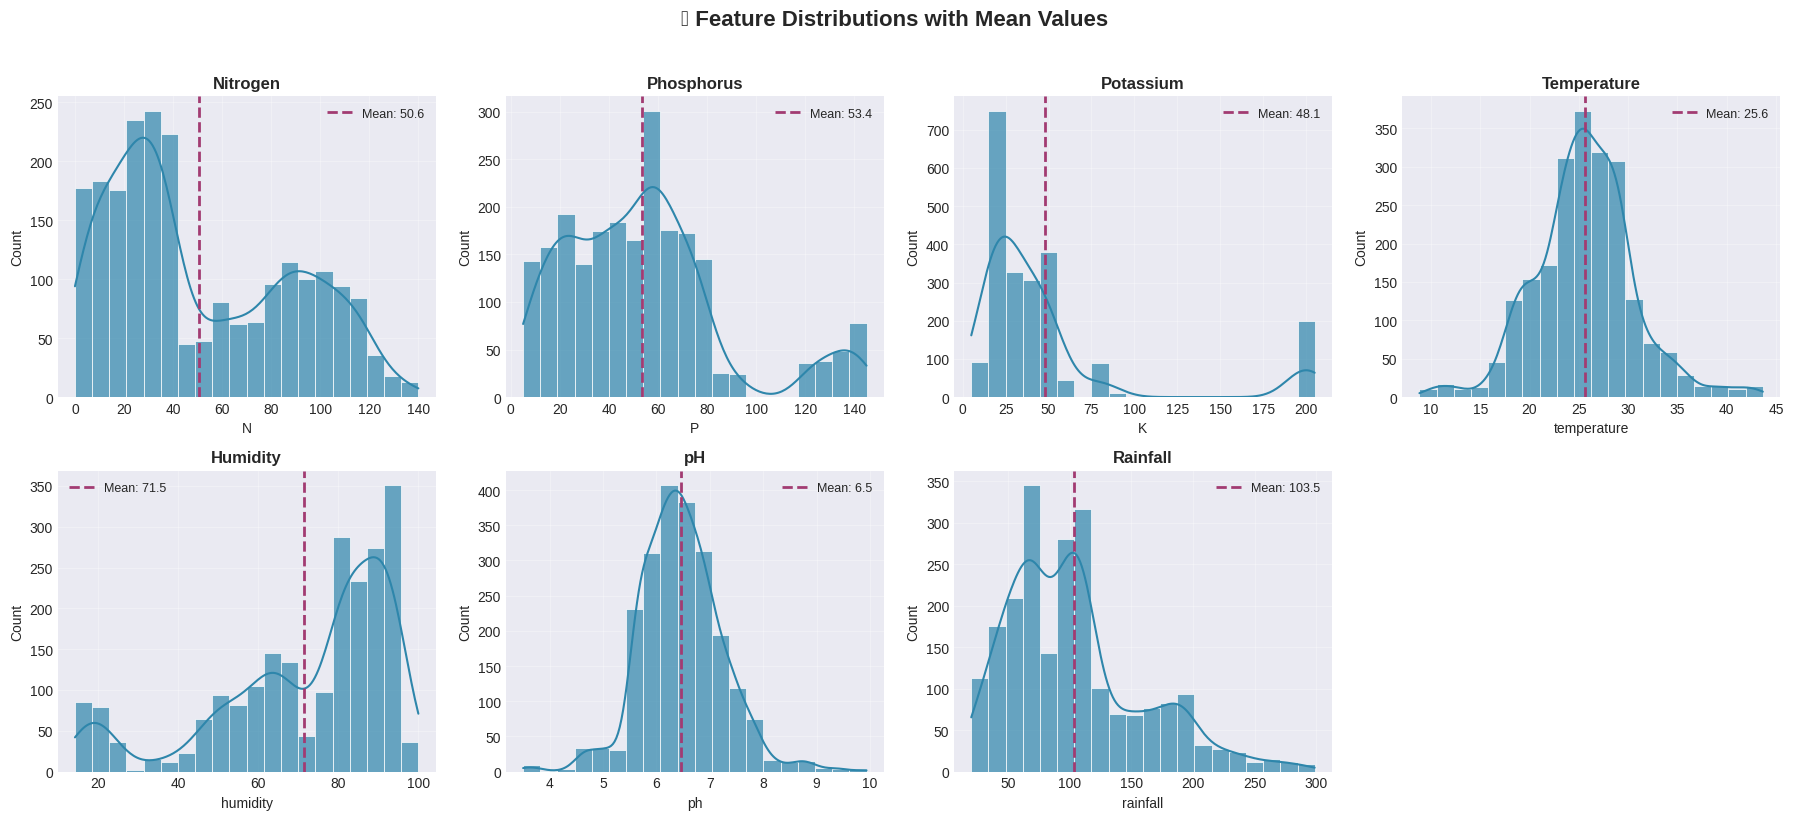

In [9]:
# 4.2 Feature Distributions with KDE
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, feature_labels)):
    # Create histogram with KDE
    sns.histplot(data=df, x=feat, kde=True, ax=axes[i], color='#2E86AB',
                 bins=20, alpha=0.7, edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[feat].mean(), color='#A23B72', linestyle='--', linewidth=2,
                    label=f'Mean: {df[feat].mean():.1f}')
    axes[i].set_title(label, fontweight='bold', fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('📊 Feature Distributions with Mean Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

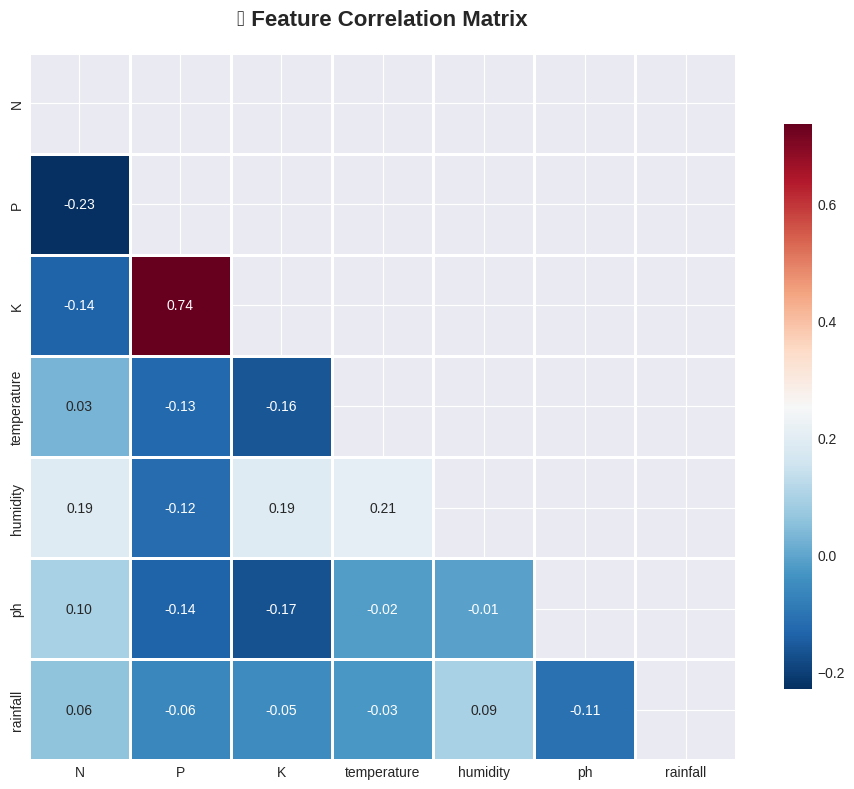

In [10]:
# 4.3 Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=1, annot_kws={'size': 10}, square=True,
            cbar_kws={"shrink": 0.8})
plt.title('🔗 Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


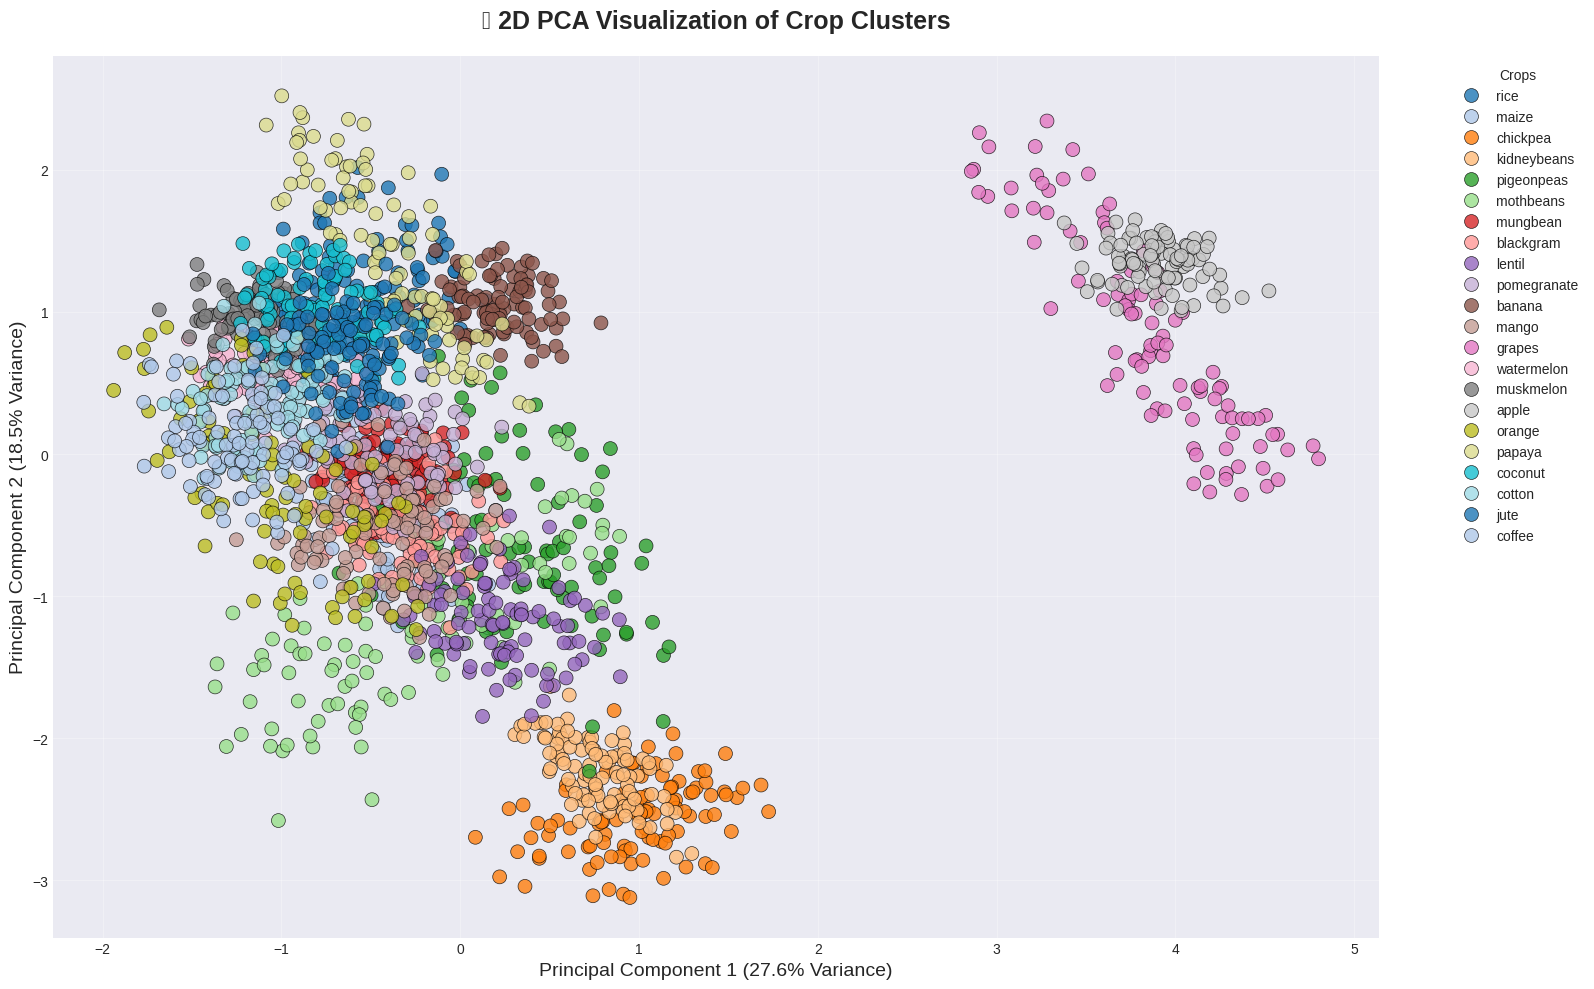

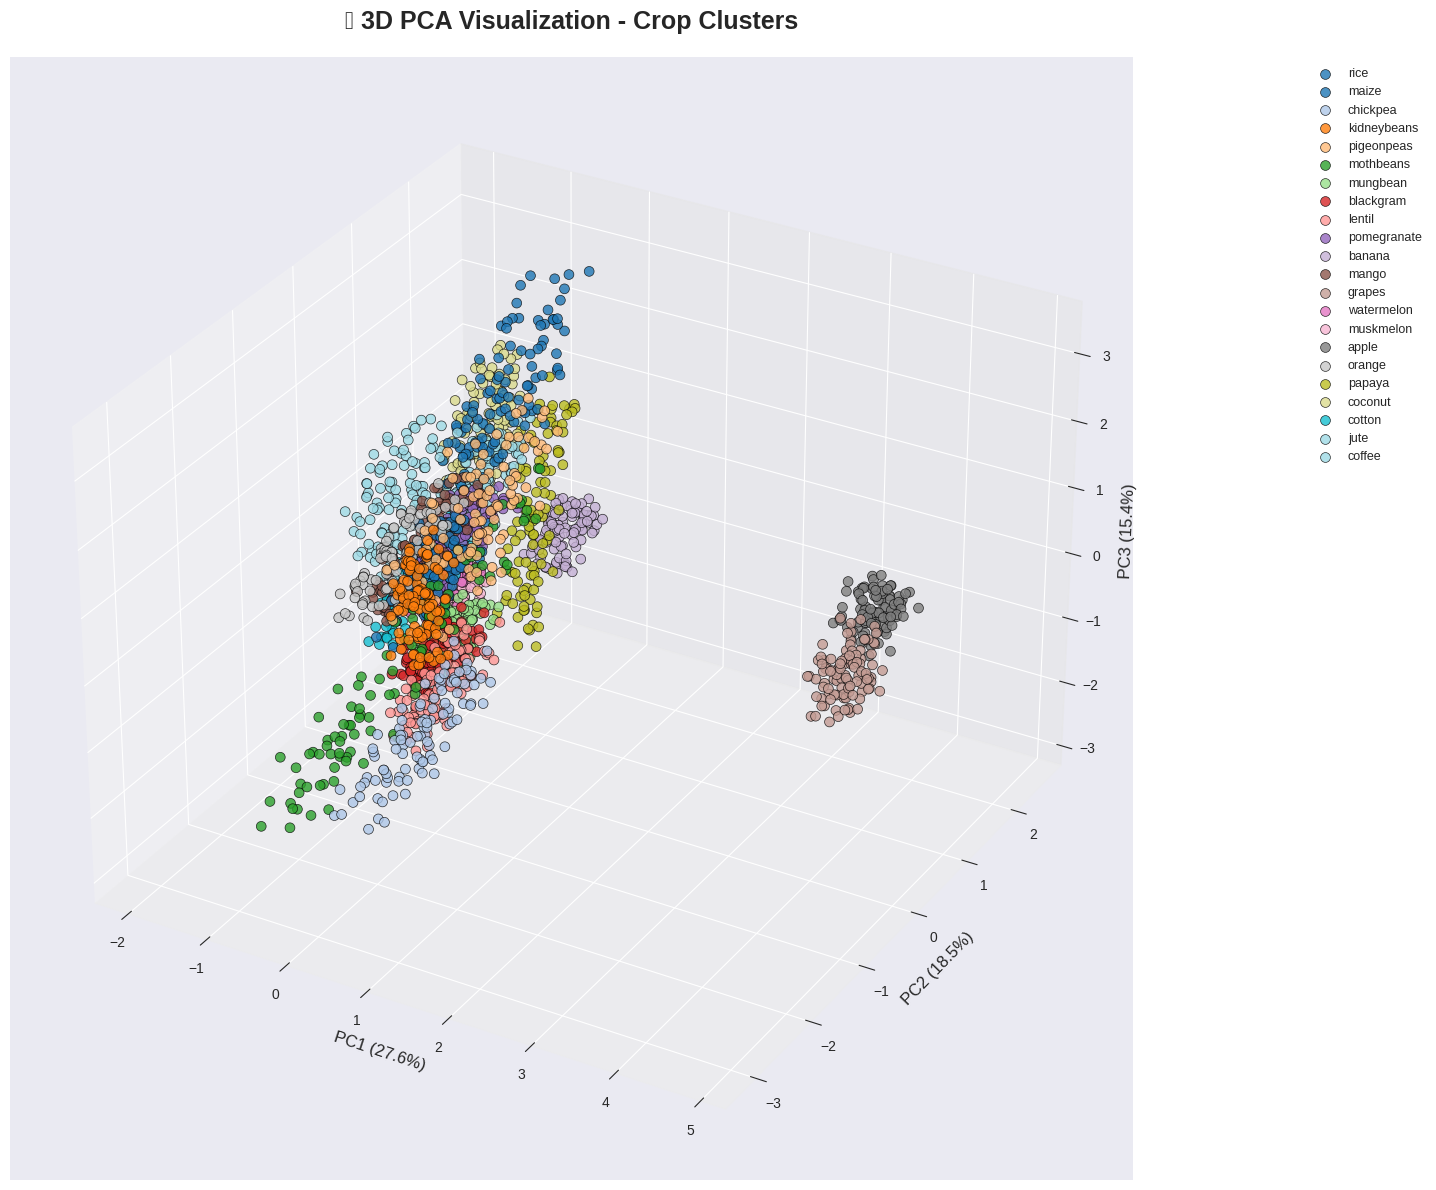

In [11]:
# 4.4 PCA VISUALIZATION (2D and 3D)

# Prepare data for PCA
X_scaled = StandardScaler().fit_transform(df[features])
y = df['label']

# 2D PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df_2d = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Crop': y
})

# 2D PCA Plot
plt.figure(figsize=(16, 10))
scatter = sns.scatterplot(data=pca_df_2d, x='PC1', y='PC2',
                          hue='Crop', palette='tab20',
                          s=100, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add variance explained info
var_explained = pca_2d.explained_variance_ratio_ * 100
plt.xlabel(f'Principal Component 1 ({var_explained[0]:.1f}% Variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({var_explained[1]:.1f}% Variance)', fontsize=14)
plt.title('🌈 2D PCA Visualization of Crop Clusters', fontsize=18, fontweight='bold', pad=20)

# Add legend with better positioning
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='Crops')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3D PCA
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with colors
colors = plt.cm.tab20(np.linspace(0, 1, len(df['label'].unique())))
for i, crop in enumerate(df['label'].unique()):
    mask = y == crop
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=[colors[i]], label=crop, s=50, alpha=0.8, edgecolors='black', linewidth=0.5)

# Add variance explained
var_3d = pca_3d.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var_3d[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_3d[1]:.1f}%)', fontsize=12)
ax.set_zlabel(f'PC3 ({var_3d[2]:.1f}%)', fontsize=12)
ax.set_title('🎯 3D PCA Visualization - Crop Clusters', fontsize=18, fontweight='bold', pad=20)

# Add legend
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

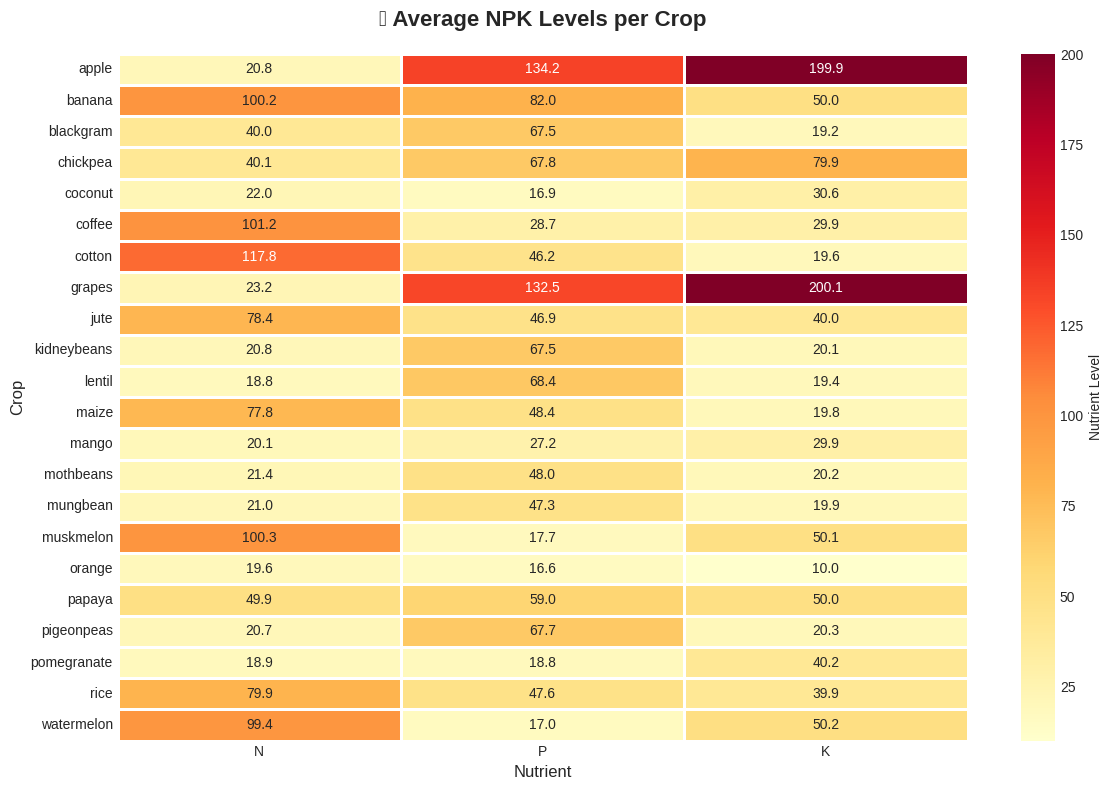

In [12]:
# 4.5 Nutrient Profiles Heatmap (N, P, K only )
pivot_npk = df.groupby('label')[['N', 'P', 'K']].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_npk, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, cbar_kws={'label': 'Nutrient Level'})
plt.title('🌱 Average NPK Levels per Crop', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nutrient', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# ---------- Step 5: Prepare Data ----------

X = df[features]
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"\n📈 Training samples : {X_train_sc.shape[0]}")
print(f"📉 Testing samples  : {X_test_sc.shape[0]}")



📈 Training samples : 1760
📉 Testing samples  : 440



🎯 Best K = 13 | Accuracy = 98.18%


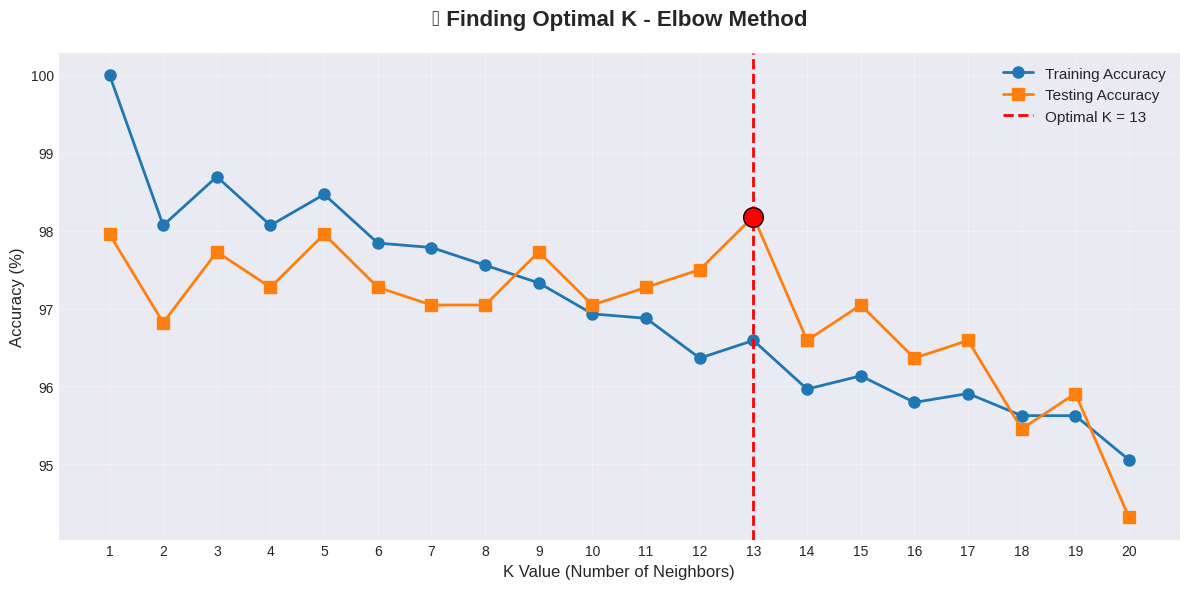

In [14]:
# ---------- Step 6: Find Best K (Optimized) ----------

train_acc, test_acc = [], []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_sc)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_sc)))

best_k = k_range[np.argmax(test_acc)]
best_acc = max(test_acc) * 100

print(f"\n🎯 Best K = {best_k} | Accuracy = {best_acc:.2f}%")

# Elbow plot -
plt.figure(figsize=(12, 6))
plt.plot(k_range, [a*100 for a in train_acc], 'o-', label='Training Accuracy',
         color='#1f77b4', linewidth=2, markersize=8)
plt.plot(k_range, [a*100 for a in test_acc], 's-', label='Testing Accuracy',
         color='#ff7f0e', linewidth=2, markersize=8)
plt.axvline(best_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal K = {best_k}')
plt.scatter([best_k], [best_acc], color='red', s=200, zorder=5, edgecolor='black')

plt.title('🎯 Finding Optimal K - Elbow Method', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('K Value (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# ---------- Step 7: Train Final Model ----------

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train)

y_pred = knn_model.predict(X_test_sc)

train_score = accuracy_score(y_train, knn_model.predict(X_train_sc)) * 100
test_score = accuracy_score(y_test, y_pred) * 100

print(f"\n✅ Training Accuracy : {train_score:.2f}%")
print(f"✅ Testing Accuracy  : {test_score:.2f}%")



✅ Training Accuracy : 96.59%
✅ Testing Accuracy  : 98.18%



📊 10-Fold Cross Validation:
   Mean Accuracy : 95.40%
   Std Deviation : 1.51%


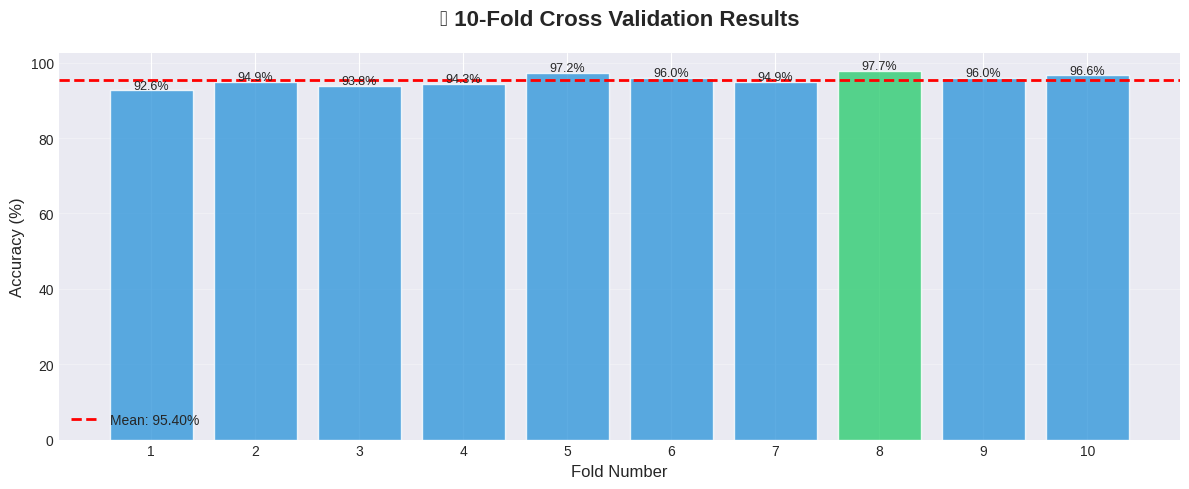

In [16]:
# ---------- Step 8: Cross Validation ----------

cv_scores = cross_val_score(knn_model, X_train_sc, y_train, cv=10, scoring='accuracy')

print(f"\n📊 10-Fold Cross Validation:")
print(f"   Mean Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"   Std Deviation : {cv_scores.std()*100:.2f}%")

# Cross-validation plot
plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if s == max(cv_scores) else '#3498db' for s in cv_scores]
bars = plt.bar(range(1, 11), cv_scores * 100, color=colors,
               edgecolor='white', linewidth=1, alpha=0.8)

# Add value labels
for bar, score in zip(bars, cv_scores * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.1f}%', ha='center', fontsize=9)

plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
            linewidth=2, label=f'Mean: {cv_scores.mean()*100:.2f}%')

plt.title('📊 10-Fold Cross Validation Results', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.90      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97       

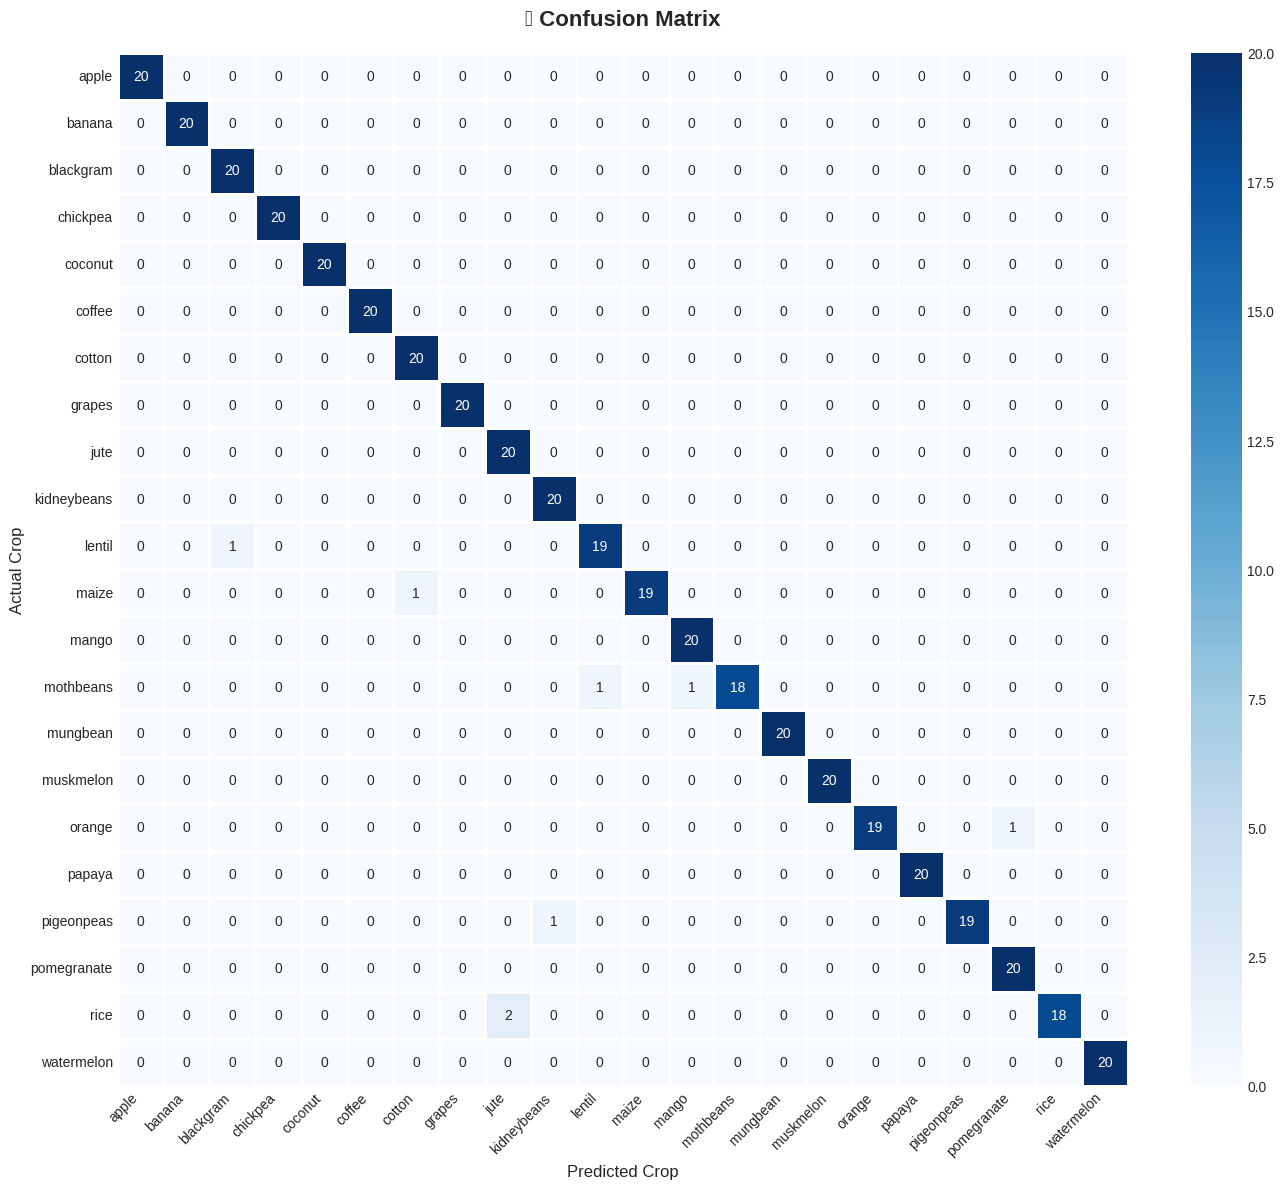

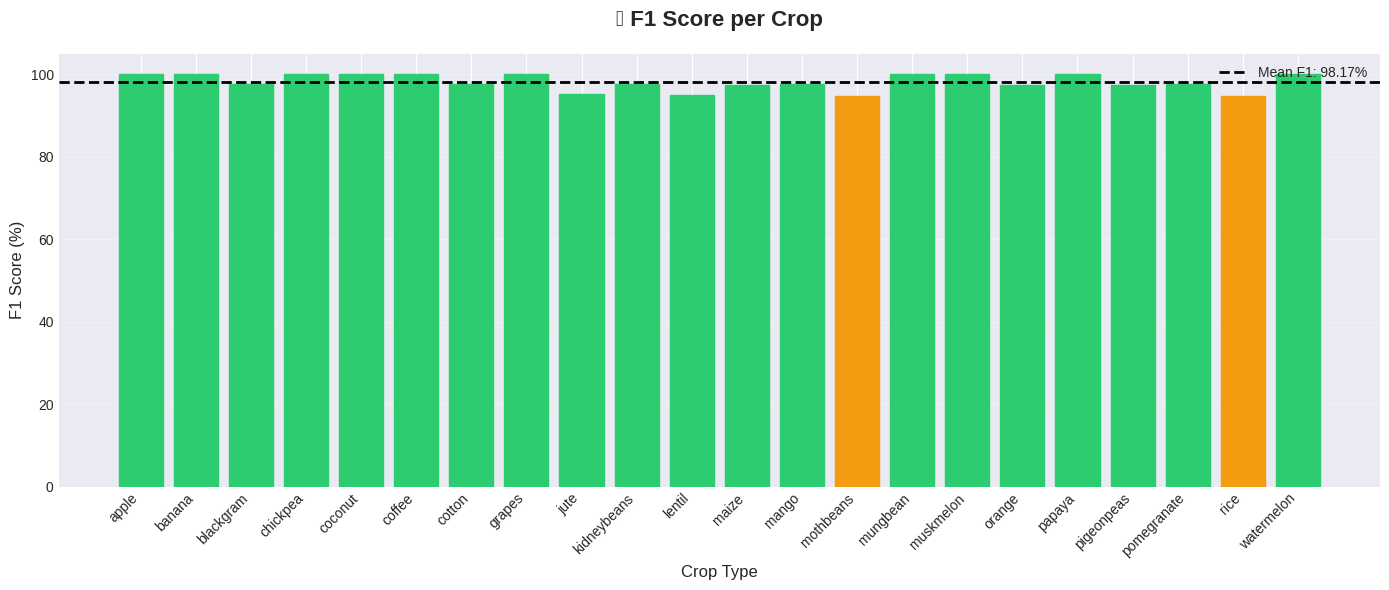

In [17]:
# ---------- Step 9: Model Evaluation ----------

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred, labels=knn_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            linewidths=1, annot_kws={'size': 10})
plt.title('🎯 Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Crop', fontsize=12)
plt.ylabel('Actual Crop', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# F1 Scores per crop
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, y_pred, average=None, labels=knn_model.classes_)

plt.figure(figsize=(14, 6))
bars = plt.bar(knn_model.classes_, f1_scores * 100,
               color=plt.cm.viridis(np.linspace(0, 1, len(f1_scores))),
               edgecolor='black', linewidth=1)

# Color-code bars based on performance
for bar, f1 in zip(bars, f1_scores):
    if f1 >= 0.95:
        bar.set_color('#2ecc71')  # Excellent
    elif f1 >= 0.90:
        bar.set_color('#f39c12')  # Good
    else:
        bar.set_color('#e74c3c')  # Needs improvement

plt.axhline(np.mean(f1_scores) * 100, color='black', linestyle='--',
            linewidth=2, label=f'Mean F1: {np.mean(f1_scores)*100:.2f}%')

plt.title('📈 F1 Score per Crop', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('F1 Score (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ---------- Step 10: Save Model ----------

joblib.dump(knn_model, 'knn_crop_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n Model saved successfully!")


 Model saved successfully!



════════════════════════════════════════════════════════════
              🌾 CROP RECOMMENDATION SYSTEM
════════════════════════════════════════════════════════════

📥 Input Parameters:
   Nitrogen: 90 kg/ha
   Phosphorus: 42 kg/ha
   Potassium: 43 kg/ha
   Temperature: 21°C
   Humidity: 82%
   pH: 6.5
   Rainfall: 200 mm

────────────────────────────────────────────────────────────
🏆 BEST CROP: RICE
────────────────────────────────────────────────────────────

📊 Top 3 Recommendations:
   🥇 1. rice            [████████████░░░░░░░░] 61.5%
   🥈 2. jute            [███████░░░░░░░░░░░░░] 38.5%
   🥉 3. pomegranate     [░░░░░░░░░░░░░░░░░░░░] 0.0%

════════════════════════════════════════════════════════════


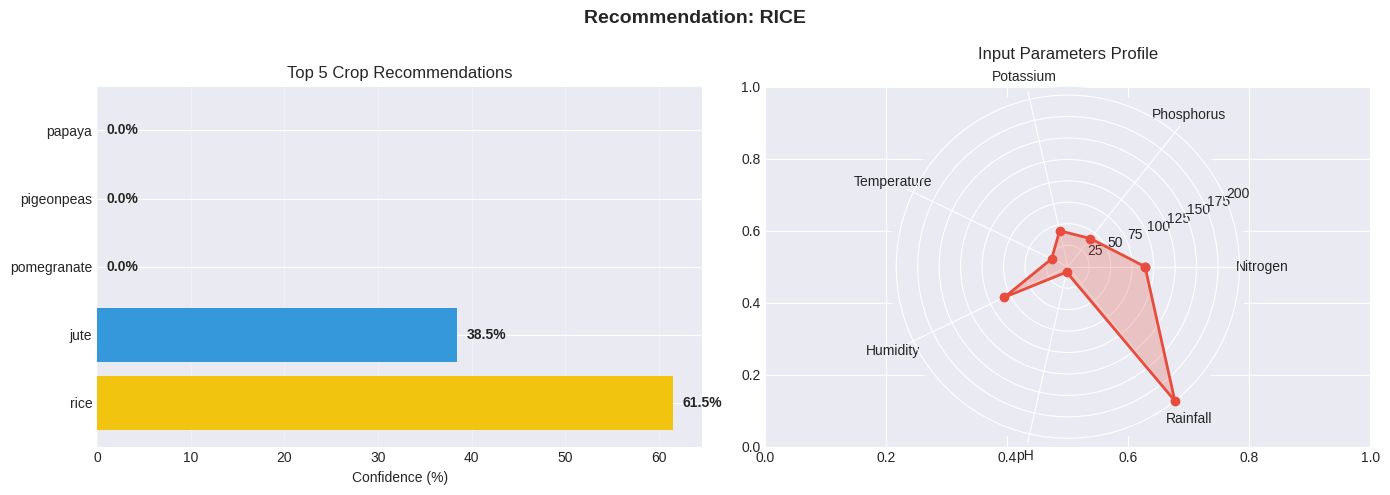


════════════════════════════════════════════════════════════
              🌾 CROP RECOMMENDATION SYSTEM
════════════════════════════════════════════════════════════

📥 Input Parameters:
   Nitrogen: 20 kg/ha
   Phosphorus: 30 kg/ha
   Potassium: 12 kg/ha
   Temperature: 26°C
   Humidity: 50%
   pH: 7.2
   Rainfall: 65 mm

────────────────────────────────────────────────────────────
🏆 BEST CROP: MOTHBEANS
────────────────────────────────────────────────────────────

📊 Top 3 Recommendations:
   🥇 1. mothbeans       [████████████░░░░░░░░] 61.5%
   🥈 2. mango           [████░░░░░░░░░░░░░░░░] 23.1%
   🥉 3. blackgram       [█░░░░░░░░░░░░░░░░░░░] 7.7%

════════════════════════════════════════════════════════════


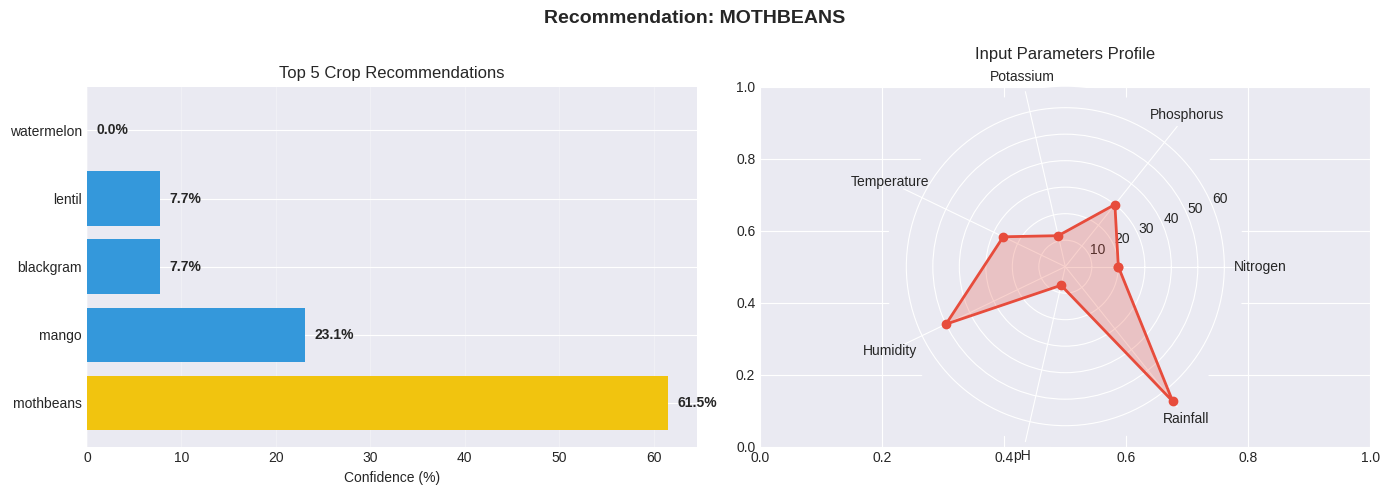


════════════════════════════════════════════════════════════
              📝 CUSTOM INPUT MODE
════════════════════════════════════════════════════════════
Nitrogen (N) [kg/ha]: 52
Phosphorus (P) [kg/ha]: 36
Potassium (K) [kg/ha]: 25
Temperature [°C]: 30
Humidity [%]: 50
Soil pH: 7.5
Rainfall [mm/year]: 200

════════════════════════════════════════════════════════════
              🌾 CROP RECOMMENDATION SYSTEM
════════════════════════════════════════════════════════════

📥 Input Parameters:
   Nitrogen: 52.0 kg/ha
   Phosphorus: 36.0 kg/ha
   Potassium: 25.0 kg/ha
   Temperature: 30.0°C
   Humidity: 50.0%
   pH: 7.5
   Rainfall: 200.0 mm

────────────────────────────────────────────────────────────
🏆 BEST CROP: COFFEE
────────────────────────────────────────────────────────────

📊 Top 3 Recommendations:
   🥇 1. pigeonpeas      [███████░░░░░░░░░░░░░] 38.5%
   🥈 2. coffee          [███████░░░░░░░░░░░░░] 38.5%
   🥉 3. jute            [████░░░░░░░░░░░░░░░░] 23.1%

════════════════════════

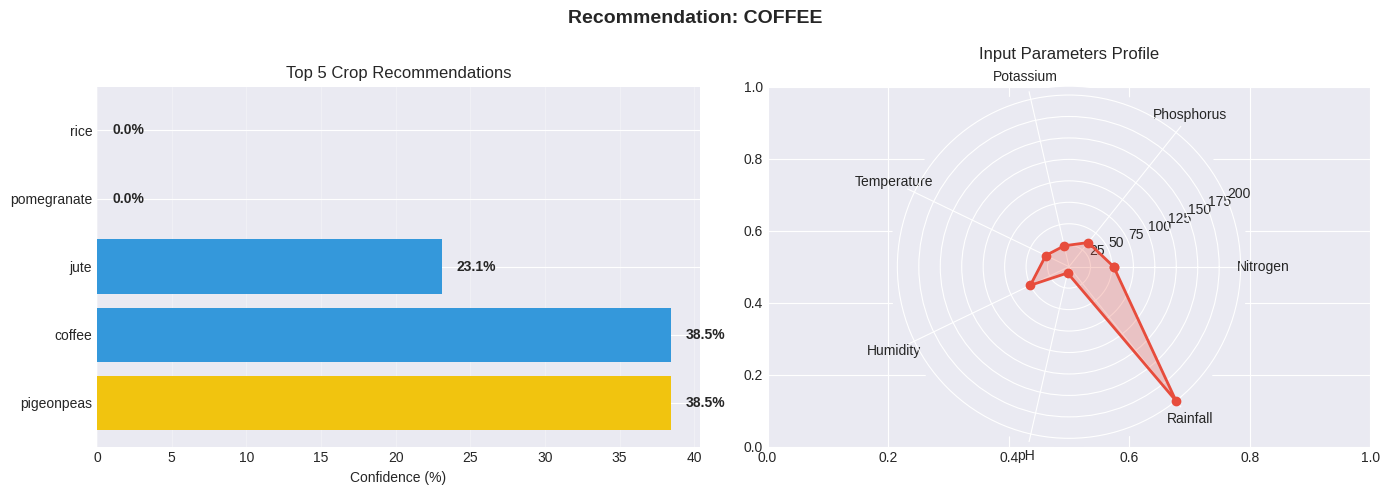

In [19]:
# ---------- Step 11: Enhanced Prediction Function ----------

def recommend_crop_stunning(N, P, K, temperature, humidity, ph, rainfall):
    """
    Stunning crop recommendation with visual feedback.
    """
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_scaled = scaler.transform(input_data)

    # Get prediction and probabilities
    prediction = knn_model.predict(input_scaled)[0]
    probabilities = knn_model.predict_proba(input_scaled)[0]

    # Top 3 crops
    top3_idx = np.argsort(probabilities)[::-1][:3]
    top3_crops = [(knn_model.classes_[i], probabilities[i] * 100) for i in top3_idx]

    # Display results in a beautiful format
    print("\n" + "═" * 60)
    print("              🌾 CROP RECOMMENDATION SYSTEM")
    print("═" * 60)

    print("\n📥 Input Parameters:")
    params = [
        f"Nitrogen: {N} kg/ha", f"Phosphorus: {P} kg/ha", f"Potassium: {K} kg/ha",
        f"Temperature: {temperature}°C", f"Humidity: {humidity}%",
        f"pH: {ph}", f"Rainfall: {rainfall} mm"
    ]

    for i, param in enumerate(params, 1):
        print(f"   {param}")

    print("\n" + "─" * 60)
    print(f"🏆 BEST CROP: {prediction.upper()}")
    print("─" * 60)

    print("\n📊 Top 3 Recommendations:")
    for rank, (crop, prob) in enumerate(top3_crops, 1):
        bar_length = int(prob / 5)
        bar = "█" * bar_length + "░" * (20 - bar_length)
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
        print(f"   {medal} {rank}. {crop:<15} [{bar}] {prob:.1f}%")

    print("\n" + "═" * 60)

    # Visual representation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart for top 5 recommendations
    top5_idx = np.argsort(probabilities)[::-1][:5]
    top5_crops = [knn_model.classes_[i] for i in top5_idx]
    top5_probs = [probabilities[i] * 100 for i in top5_idx]

    colors = ['#f1c40f' if i == 0 else '#3498db' for i in range(5)]
    bars = ax1.barh(range(len(top5_crops)), top5_probs, color=colors)
    ax1.set_yticks(range(len(top5_crops)))
    ax1.set_yticklabels(top5_crops)
    ax1.set_xlabel('Confidence (%)')
    ax1.set_title('Top 5 Crop Recommendations')
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, prob in zip(bars, top5_probs):
        ax1.text(prob + 1, bar.get_y() + bar.get_height()/2, f'{prob:.1f}%',
                va='center', fontweight='bold')

    # Radar chart for input parameters
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    values = input_data.flatten().tolist()
    values += values[:1]  # Complete the circle
    angles += angles[:1]

    ax2 = plt.subplot(122, projection='polar')
    ax2.plot(angles, values, 'o-', linewidth=2, color='#e74c3c')
    ax2.fill(angles, values, alpha=0.25, color='#e74c3c')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(feature_labels)
    ax2.set_title('Input Parameters Profile', pad=20)

    plt.suptitle(f'Recommendation: {prediction.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return prediction


# Test the enhanced function
recommend_crop_stunning(N=90, P=42, K=43, temperature=21, humidity=82, ph=6.5, rainfall=200)
recommend_crop_stunning(N=20, P=30, K=12, temperature=26, humidity=50, ph=7.2, rainfall=65)


# Interactive input
print("\n" + "═" * 60)
print("              📝 CUSTOM INPUT MODE")
print("═" * 60)

try:
    N = float(input("Nitrogen (N) [kg/ha]: "))
    P = float(input("Phosphorus (P) [kg/ha]: "))
    K = float(input("Potassium (K) [kg/ha]: "))
    temperature = float(input("Temperature [°C]: "))
    humidity = float(input("Humidity [%]: "))
    ph = float(input("Soil pH: "))
    rainfall = float(input("Rainfall [mm/year]: "))

    recommend_crop_stunning(N, P, K, temperature, humidity, ph, rainfall)

except ValueError:
    print("❌ Invalid input. Please enter numeric values.")